In [1]:
import numpy as np
import pandas as pd
from BezierSpline import BezierCurve, BSpline
from plotnine.ggplot import ggplot
from plotnine import *

In [2]:
dfc = pd.DataFrame({"x":[0, 1, 3, 4], "y": [0,2,2,0]})
bc = BezierCurve(dfc.to_numpy())
dfp = pd.DataFrame(bc.value(np.arange(0, 1, 0.01)), columns=["x", "y"])

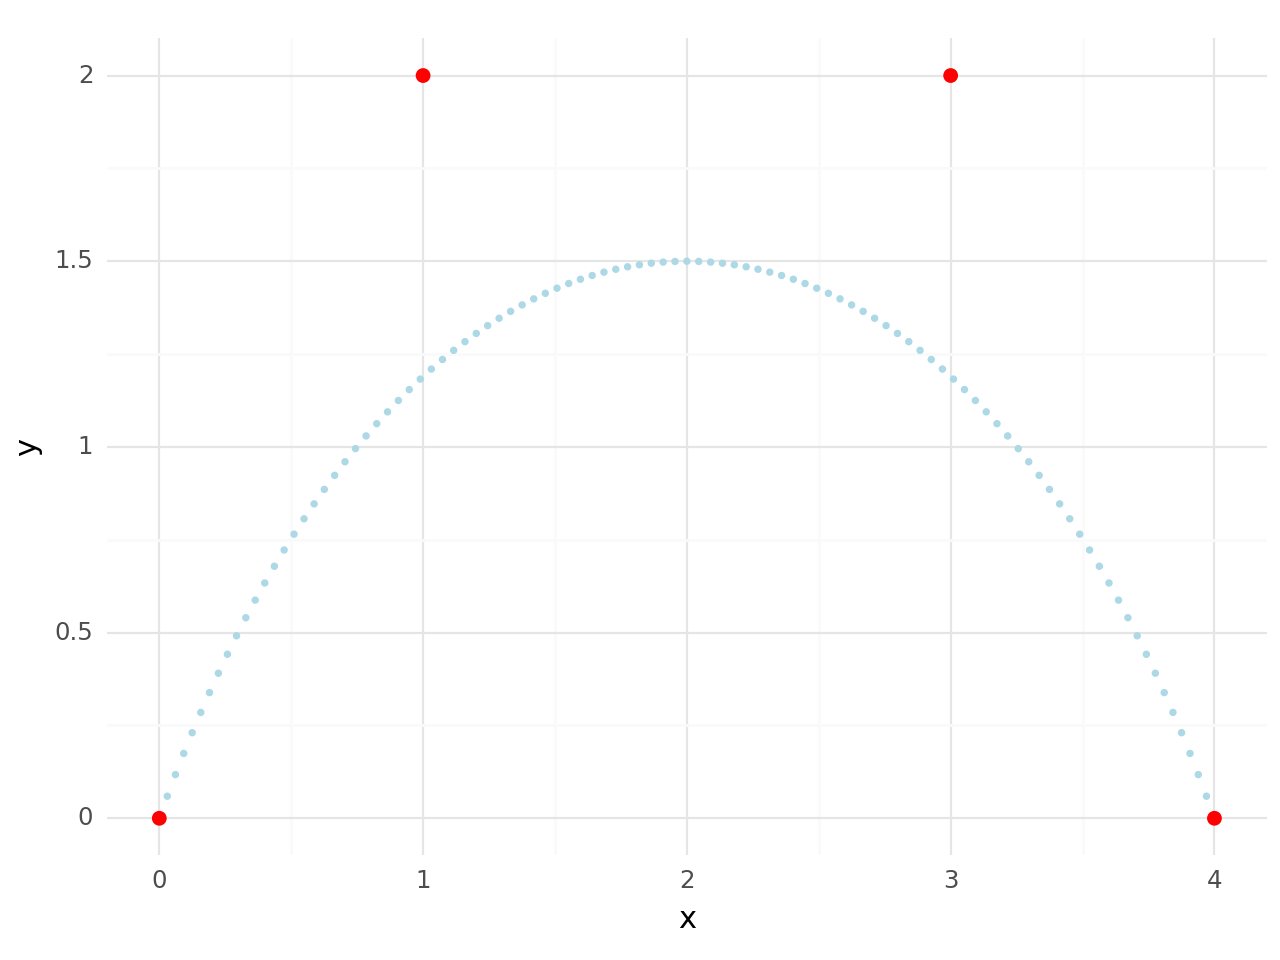

<Figure Size: (640 x 480)>

In [3]:
theme_set(theme_minimal)
(
    ggplot(aes("x", "y"))
    + geom_point(data=dfp, color = "lightblue", size=.5)
    + geom_point(data=dfc, color = "red", size=2)
)

In [4]:
bs = BSpline(dfc.to_numpy())
dfs = pd.DataFrame(bs.value(np.arange(0, 1, 0.01)), columns=["x", "y"])

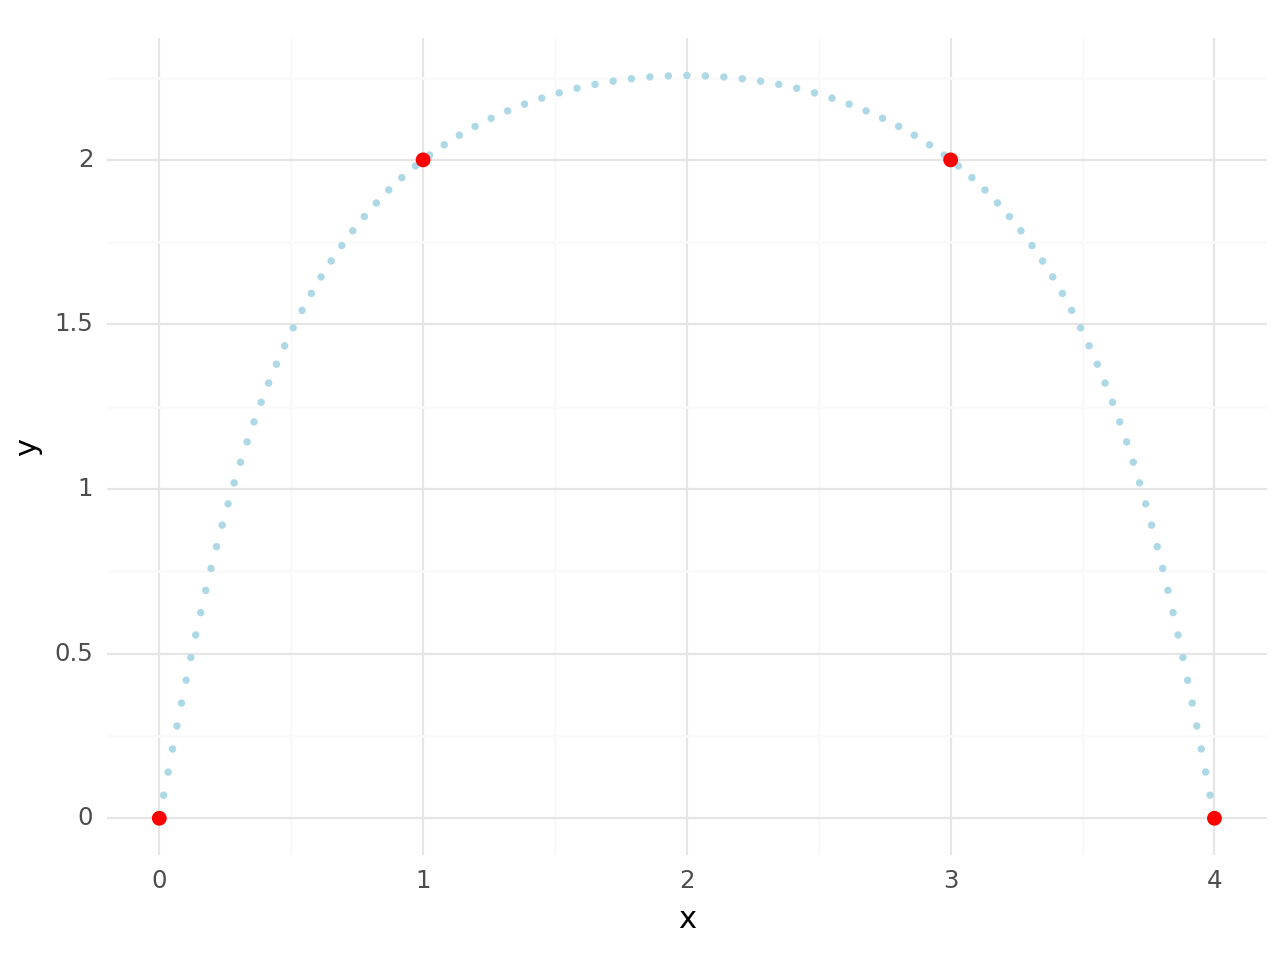

<Figure Size: (640 x 480)>

In [5]:
(
    ggplot(aes("x", "y"))
    + geom_point(data=dfs, color="lightblue", size=0.5)
    + geom_point(data=dfc, color="red", size=2)
)

In [6]:
from SplineFit import SplineFit

In [7]:
x = np.random.uniform(0, np.pi, 200)
y = np.sin(x)
pt = np.stack([x, y], axis=1)

In [8]:
ptn = pt + np.random.normal(0, 0.05, [200, 2])

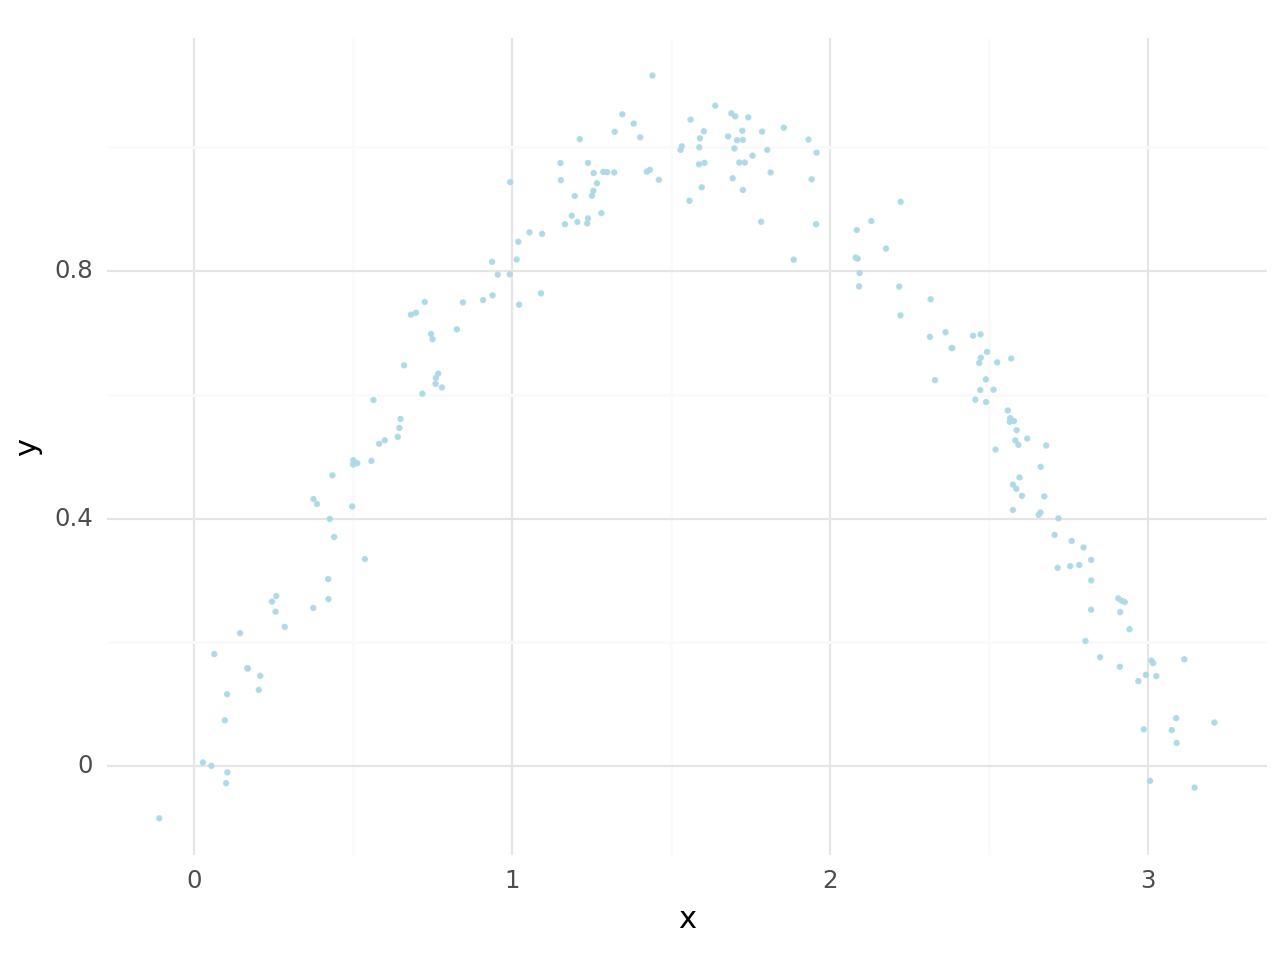

<Figure Size: (640 x 480)>

In [9]:
p1 = (
    ggplot(pd.DataFrame(ptn, columns=["x", "y"]), aes("x", "y")) 
    + geom_point(color="lightblue", alpha=0.9, size=0.3)
)
p1

First cluster built: _PCACluster(center=[1.18761932 0.88913162], centroid=[1.20011892 0.91386308], radius=0.2, mld=[-0.86447204 -0.50268091]).
Moving forward...
Built forward cluster: _PCACluster(center=[1.02722451 0.8133269 ], centroid=[1.03403704 0.82919437], radius=0.2, mld=[-0.89316818 -0.4497228 ]).
Built forward cluster: _PCACluster(center=[0.85540341 0.73924981], centroid=[0.84205147 0.72369965], radius=0.2, mld=[-0.88326885 -0.46886686]).
Built forward cluster: _PCACluster(center=[0.6653977  0.62992628], centroid=[0.68975235 0.62188338], radius=0.2, mld=[-0.70251129 -0.7116726 ]).
Built forward cluster: _PCACluster(center=[0.54925009 0.47954886], centroid=[0.52036321 0.47589892], radius=0.2, mld=[-0.81009434 -0.58629955]).
Built forward cluster: _PCACluster(center=[0.35834435 0.35863901], centroid=[0.39738874 0.3545581 ], radius=0.2, mld=[-0.71235461 -0.70181971]).
Built forward cluster: _PCACluster(center=[0.25491782 0.21419415], centroid=[0.23701538 0.21005517], radius=0.2, m

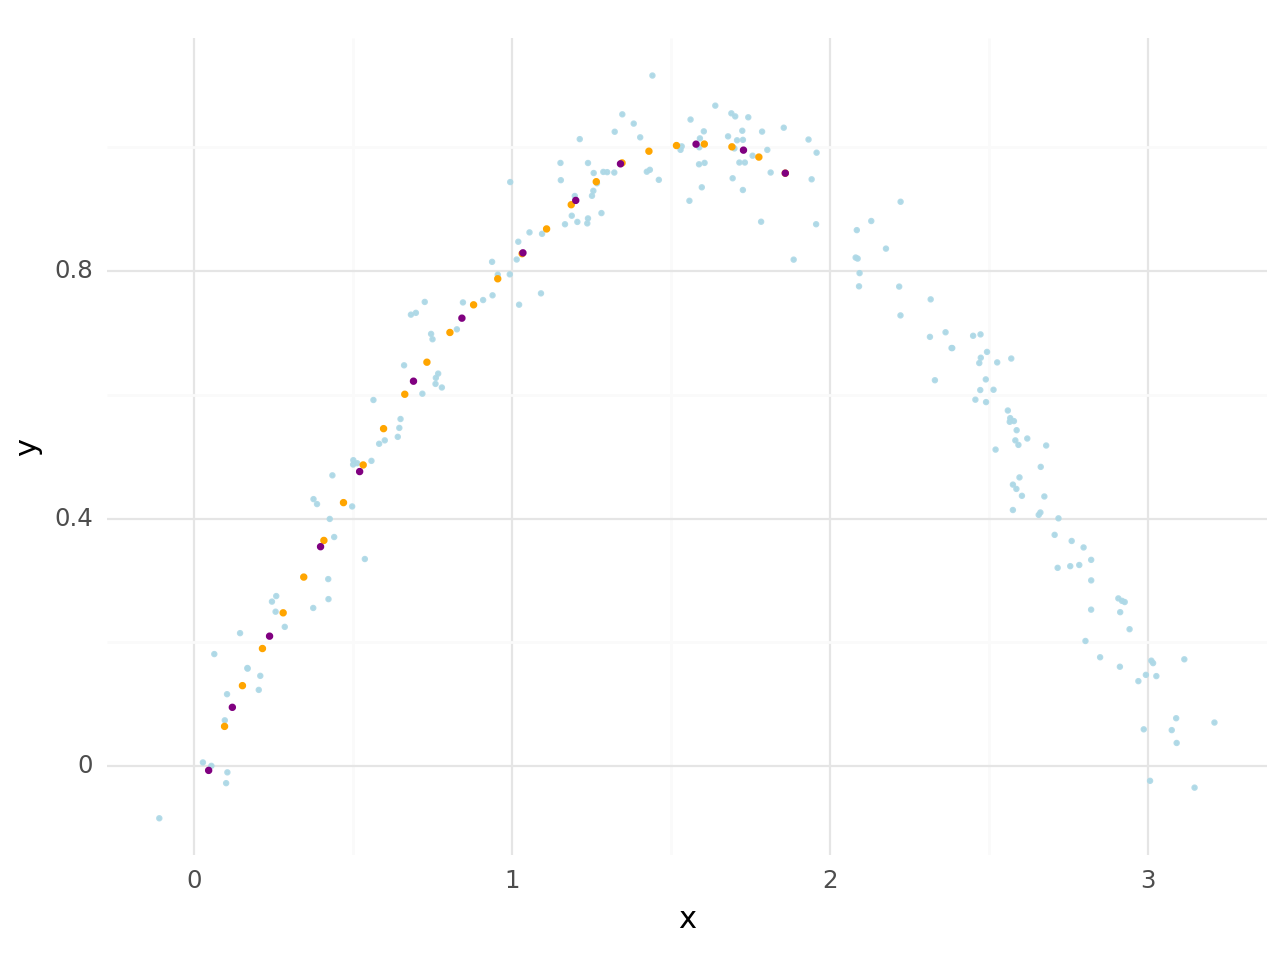

<Figure Size: (640 x 480)>

In [10]:
sin_fit = SplineFit(ptn, np.zeros(1), radius=0.2, verbose=2)
sin_fit.build_clusters(42)
sin_fit.order()
sin_oc = sin_fit.oc

dfc = pd.DataFrame(sin_oc.value(np.arange(0, 1, 0.04)), columns=["x", "y"])
(
    p1
    + geom_point(data=dfc, color="orange", size=0.5)
    + geom_point(
        data=pd.DataFrame(sin_oc.controls, columns=["x", "y"]), color="purple", size=0.5
    )
)